# Spor Bahislerinde Kullanıcı Segmentasyonu ve Davranışsal Profil Analizi

Bu pipeline, spor bahis platformlarında kullanıcıların bahis alışkanlıklarını ve davranış kalıplarını analiz ederek farklı kullanıcı profilleri oluşturmayı amaçlamaktadır. **Veri seti**, 5000 kullanıcı tarafından yapılan 100.000 bahis işleminden oluşmakta ve gerçekçi bahis davranışlarını simüle etmektedir.

## 1. Proje Tanımı ve Veri Hakkında

Elimizde **bets1.xlsx*** adlı bir Excel dosyası bulunmaktadır. Dosya içeriğinde her satır bir bahis işlemine karşlık gelmektedir ve aşağıdaki sütunları içermektedir:

- **bet_id**: Bahsin benzersiz kimliği
- **user_id**: Bahsi yapan kullanıcının kimliği
- **bet_type**: Tekli (single) veya çoklu (multiple) bahsi belirtir
- **sport**: Futbol, tenis, basketbol vb. olmak üzere 12 farklı spor dalı
- **odds**: Bahsin oranı
- **is_win**: Bahsin kazanıp kazanıp kazanmadığı (binary, 1 - kazandı, 0 - kaybetti)
- **stake**: Bahse yatırılan para miktarı
- **gain**: Bahisten elde edilen kazanç (kaybedilen bahiste 0)
- **GGR**: "Gross Gaming Revenue" olarak bilinen, kazançtan kesilen işletme gelirini temsil eden bir metrik

Toplamda 100.000 satır ve 9 sütun bulunmaktadır. İlk amaç, veriyi anladıktan sonra segmentasyon (clustering) için uygun hale getirmek ve doğru küme sayısını belirlemektir.

Kümeleme algoritmalarının değerlendirilmesi için **silhouette skoru** kullanılacaktır. Silhouette değeri, bir nesnenin kendi kümesine ne kadar yakın olduğunu diğer kümelerle karşılatırarak ölçer; değer -1 ile 1 arasında değişir ve büyük değerler kümenin iyi tanımlandığını gösterir. Silhouette skoru düşük veya negatif olduğunda, kümeleme yapılandırmasının doğru olmadığı anlamına gelmektedir. Ayrıca kümeler arası benzerliği deperlendiren **Davies-Bouldin indeksi** ve küme ayrıklığını değerlendiren **Calinski-Harabasz skoru** da kullanılacaktır.

In [100]:
# Gerekli kütüphanelerin import edilmesi

import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
# Dosyayı içeri aktarma

data = pd.read_excel("bets1.xlsx")

# Veri seti hakkında temel bilgilerin görüntülenmesi

print(f"Satır sayısı: {data.shape[0]}")
print(f"Sütun sayısı: {data.shape[1]}")
print("Sütun adları:", list(data.columns))

data.info()
data.describe()

# İlk beş satırın görüntülenmesi

data.head()

Satır sayısı: 100000
Sütun sayısı: 9
Sütun adları: ['bet_id', 'user_id', 'bet_type', 'sport', 'odds', 'is_win', 'stake', 'gain', 'GGR']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   bet_id    100000 non-null  object 
 1   user_id   100000 non-null  int64  
 2   bet_type  100000 non-null  object 
 3   sport     100000 non-null  object 
 4   odds      100000 non-null  float64
 5   is_win    100000 non-null  int64  
 6   stake     100000 non-null  float64
 7   gain      100000 non-null  float64
 8   GGR       100000 non-null  float64
dtypes: float64(4), int64(2), object(3)
memory usage: 6.9+ MB


,bet_id,user_id,bet_type,sport,odds,is_win,stake,gain,GGR
0,bet_00001,3848,multiple,Ice Hockey,9.44,0,13.65,0.00,13.65
1,bet_00002,153,single,Football,8.79,0,248.45,0.00,248.45
2,bet_00003,1527,single,Football,1.50,1,3.50,5.25,-1.75
3,bet_00004,3903,single,Tennis,1.55,0,151.45,0.00,151.45
4,bet_00005,2290,single,Football,1.47,1,319.05,469.00,-149.95


## 2. Veri Keşfi ve Temizliği

Bu aşamada veri setinin genel görünümü incelenecek, tutarsızlık ve eksik değer kontrolü yapılacaktır. `isna().sum()` fonksiyonu ile her bir sütundaki eksik değerlerin *sayısı*na bakılacaktır. Son olarak, kategorik değişkenlerin dağılımları incelenecektir.

In [103]:
# Eksik değer kontrolü

print(data.isna().sum())

# Bahis türü ve spor dağılımı

print("Bahis türlerinin dağılımı:") 
print(data["bet_type"].value_counts())

print("Spor branşlarının dağılımı:")
print(data["sport"].value_counts())

bet_id      0
user_id     0
bet_type    0
sport       0
odds        0
is_win      0
stake       0
gain        0
GGR         0
dtype: int64
Bahis türlerinin dağılımı:
bet_type
single      65014
multiple    34986
Name: count, dtype: int64
Spor branşlarının dağılımı:
sport
Football        49222
Tennis          18138
Basketball       8167
Ice Hockey       5038
Volleyball       4023
Handball         3948
Snooker          3064
Baseball         2988
Table Tennis     2001
Rugby            1915
Formula 1         676
Badminton         516
Cycling           304
Name: count, dtype: int64


**NOT**: Yukarıdaki çıktılara göre; veri setinde eksik değer bulunmamaktadır. Ancak segmentasyon için *her satır (yani bahis - bet_id)* yerine *kullanıcı (user_id)* seviyesinde özellik üretmek daha anlamlı olacaktır.

Her satır tek bir bahis işlemine denk gelmektedir. Ama segmentasyonun amacı kullanıcıları birbirinden ayırmaktır. Satır bazında çalışmak davranışları parçalayarak modeli yanıltır; kullanıcı bazında özetlendiğinde ise kişinin tüm davranışı tek bir profilde görülebildiği için kümeler doğru şekilde oluşmaktadır.

## 3. Keşifsel Veri Analizi


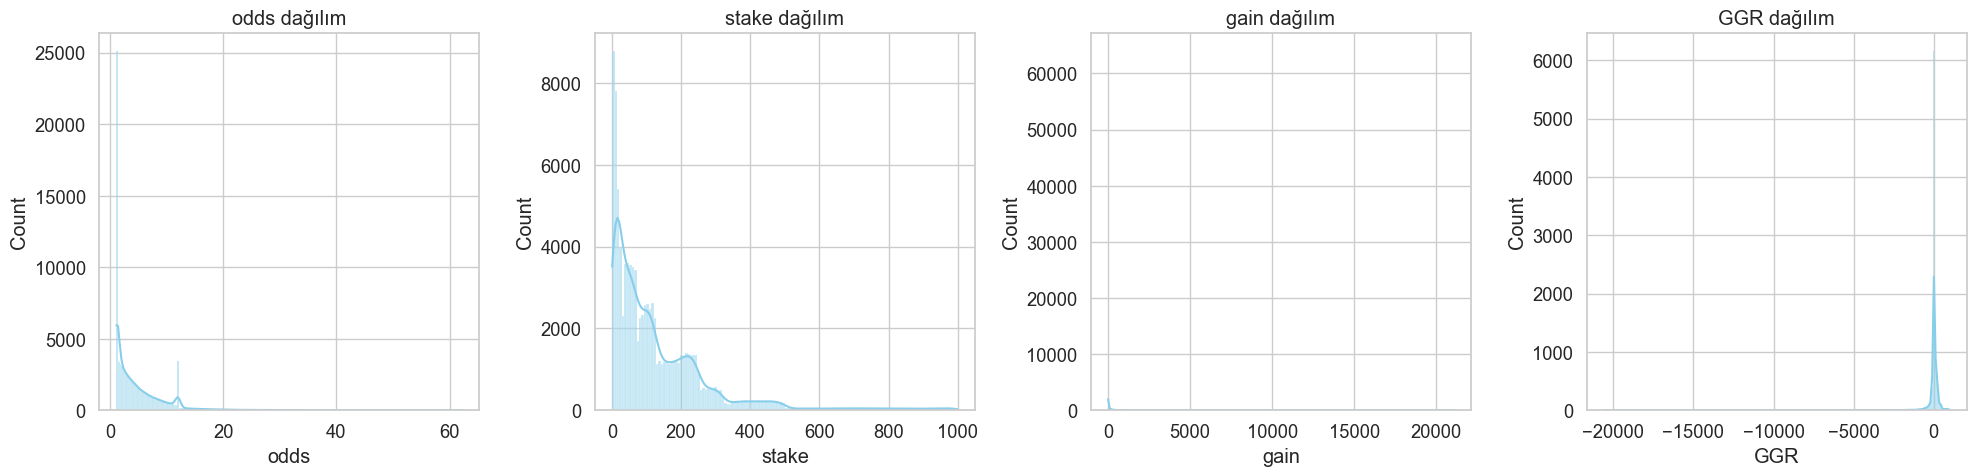

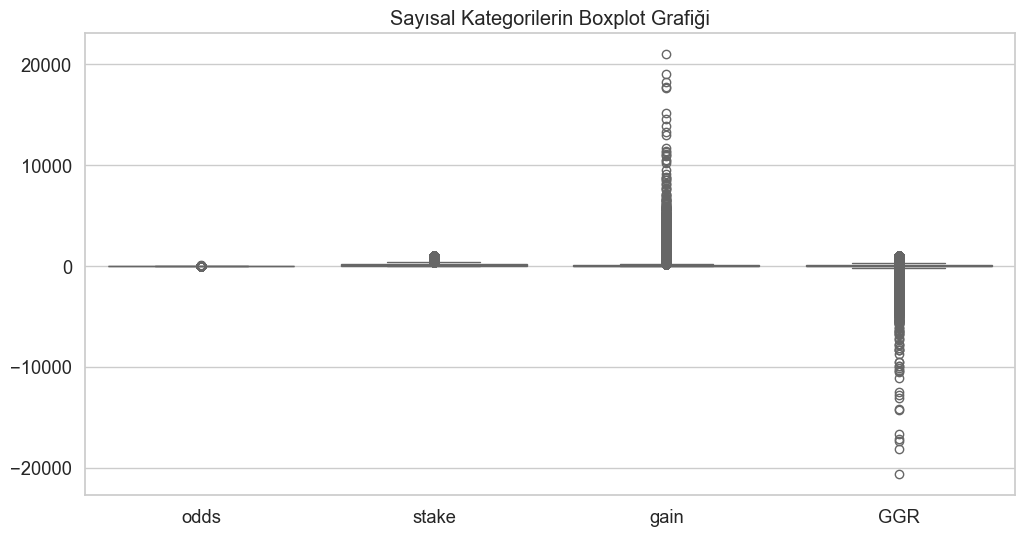

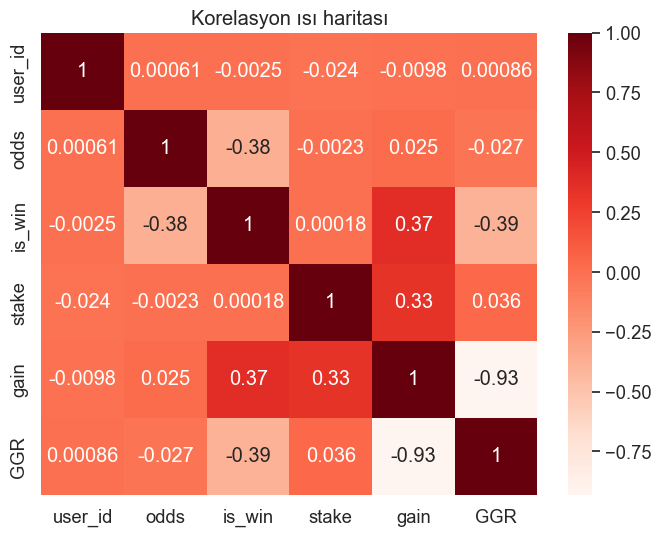

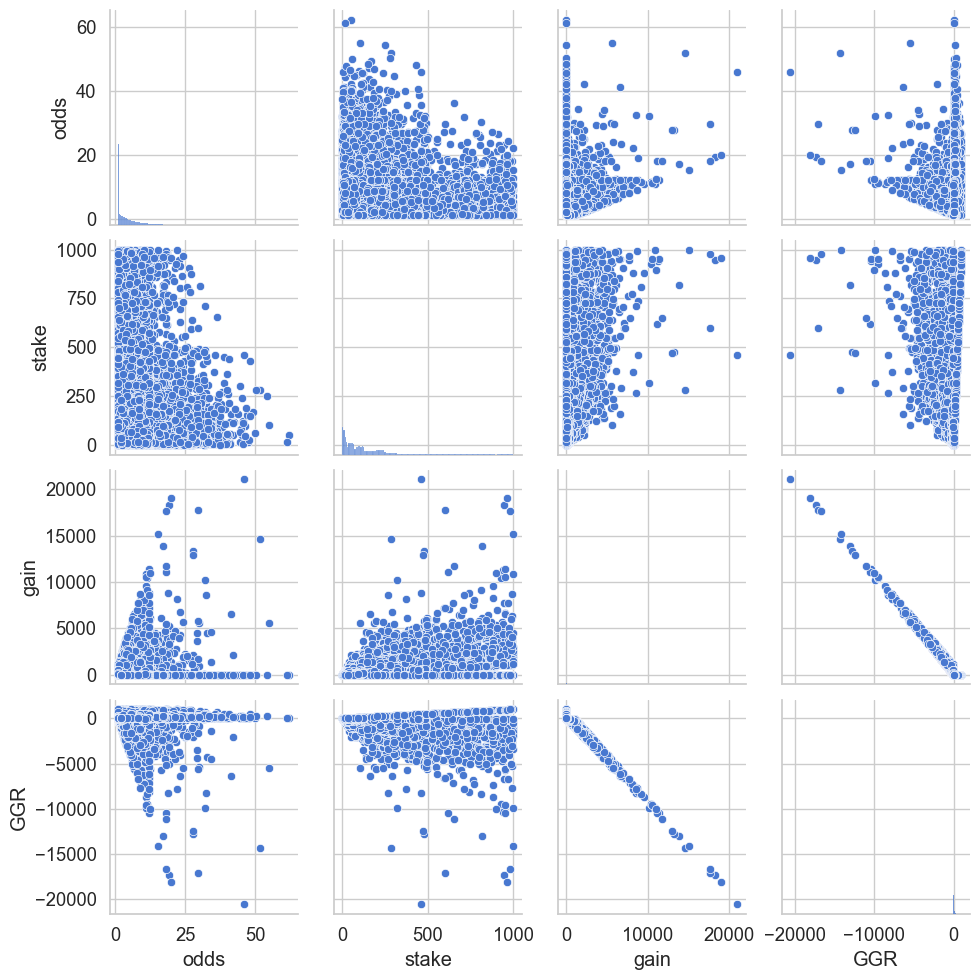

In [162]:
# Veri görselleştirme için stil ayarlama

sns.set(style='whitegrid', palette='muted', font_scale=1.2)

# 1. Sayısal sütunlar için dağılım grafikleri: odds, stake, gain, GGR

numeric_columns = ["odds", "stake", "gain", "GGR"]
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=False, sharey=False) 
for i, col in enumerate(numeric_columns):
    sns.histplot(data[col], ax=axes[i], kde=True, color="skyblue")
    axes[i].set_title(f"{col} dağılım")
plt.tight_layout()
plt.show()

# 2. Kategorik sütunlar için grafikler: bet_type, sport

sns.countplot(data=data, x="bet_type", ax=axes[0], 
              hue="bet_type",  # x değişkenini hue olarak atama
              palette="viridis", 
              legend=False)    # renkleri legend'da gösterme

sns.countplot(data=data, x="sport", ax=axes[1], 
              hue="sport",    # x değişkenini hue olarak atama
              palette="magma", 
              legend=False)    # renkleri legend'da gösterme

# 3. Sayosal değişkenlerde dağılım ve aykırı değerler için kutu grafiği

plt.figure(figsize=(12,6))
sns.boxplot(data=data[numeric_columns], palette="coolwarm")
plt.title("Sayısal Kategorilerin Boxplot Grafiği")
plt.show()

# 4. Sayısal sütunlar için korelasyon haritası

numeric_df = data.select_dtypes(include=[np.number])
plt.figure(figsize=(8,6))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap="Reds")
plt.title("Korelasyon ısı haritası")
plt.show()

# 5. Pair Plot

sns.pairplot(data[numeric_columns])
plt.show()

## Keşifsel Veri Analizi Özeti

- Kullanıcıların bahis davranışlarında belirgin farklılıklar bulunmaktadır.
- **Stake** ve **gain** dağılımlarındaki çarpıklık, düşük tutarlı fakat yüksek frekanslı bahislerin yaygın olduğunu, yüksek tutarlı aykırı değerlerin ise segmentasyon için önemli olduğunu ortaya koymaktadır.
- **Bahis sayısı, ortalama stake** ve **kazanma oranı** arasındaki varyasyon, kullanıcıların farklı risk profillerine sahip olduğunu göstermektedir.
- **Spor türleri** ve **bahis tipi** tercihlerindeki dağılım ise davranışsal segmentasyonu destekleyen ek bir ayrışma sunmaktadır.
- Bu bulgular, çok boyutlu özellik mühendisliği ve k-means tabanlı segmentasyon için güçlü bir temel oluşturmaktadır.

## 4. Kullanıcı Bazında Özellik Üretimi

Her bir kullanıcı için **bahis sayısı**, **tekli/çoklu bahis oranı**, **toplam ve ortalama para yatırma (stake)**, **toplam ve ortalama kazanç**, **kazanma oranı**, **ortalama oran (odds)** ve **her spor dalına ait bahis sayısı** gibi özet istatistikler hesaplanmıştır. Böylece her kullanıcıyı tanımlayan 40'tan fazla özellik elde edilmiştir. 

In [109]:
# Kullanıcı bazında özellik üretme

aggregated = data.groupby("user_id").agg(
    bet_count=("bet_id", "count"),
    single_count=("bet_type", lambda x: (x == "single").sum()),
    multiple_count=("bet_type", lambda x: (x == "multiple").sum()),
    total_stake=("stake", "sum"),
    mean_stake=("stake", "mean"),
    std_stake=("stake", "std"),
    total_gain=("gain", "sum"),
    mean_gain=("gain", "mean"),
    std_gain=("gain", "std"),
    win_rate=("is_win", "mean"),
    mean_odds=("odds", "mean"),
    std_odds=("odds", "std"),
    total_GGR=("GGR", "sum"),
    mean_GGR=("GGR", "mean"),
    std_GGR=("GGR", "std")
)

# Oranlar

aggregated["ratio_single"] = aggregated["single_count"] / aggregated["bet_count"]
aggregated["ratio_multiple"] = aggregated["multiple_count"] / aggregated["bet_count"]

# Spor bazında sayma ve oranlar

for sport_name in data["sport"].unique():
    cnt = (
        data[data["sport"] == sport_name]
        .groupby("user_id")["sport"]
        .count()
        .rename(f"sport_{sport_name}_count")
    )
    aggregated = aggregated.join(cnt, how="left")
    aggregated[f"sport_{sport_name}_count"] = aggregated[f"sport_{sport_name}_count"].fillna(0)
    aggregated[f"sport_{sport_name}_ratio"] = (
        aggregated[f"sport_{sport_name}_count"] / aggregated["bet_count"]
    )

# Eksik değerleri 0 ile doldurma

aggregated = aggregated.fillna(0)

print(f"Kullanıcı sayısı: {aggregated.shape[0]}")
print(f"Özellik sayısı: {aggregated.shape[1]}")
display(aggregated.head())

# Log dönüşümü uygulanacak sütunlar

log_cols = [
    "total_stake", "mean_stake",
    "total_gain", "mean_gain",
    "total_GGR", "mean_GGR"
]

# Güvenli log dönüşümü (negatif ve -1'den küçük değerleri temizleme)

for col in log_cols:
    # Değerler -1'in altına düşmesin, log1p için sınır
    safe_col = aggregated[col].clip(lower=-0.999)
    aggregated[f"log_{col}"] = np.log1p(safe_col)

Kullanıcı sayısı: 5000
Özellik sayısı: 43


,bet_count,single_count,multiple_count,total_stake,mean_stake,std_stake,total_gain,mean_gain,std_gain,win_rate,...,sport_Rugby_count,sport_Rugby_ratio,sport_Snooker_count,sport_Snooker_ratio,sport_Volleyball_count,sport_Volleyball_ratio,sport_Badminton_count,sport_Badminton_ratio,sport_Cycling_count,sport_Cycling_ratio
user_id,,,,,,,,,,,,,,,,,,,,,
1,22,16,6,776.30,35.286364,19.248984,688.01,31.273182,60.852983,0.318182,...,0.0,0.00,0.0,0.0,2.0,0.090909,0.0,0.0,0.0,0.0
2,14,7,7,70.75,5.053571,2.647819,11.06,0.790000,2.254032,0.142857,...,0.0,0.00,0.0,0.0,1.0,0.071429,0.0,0.0,0.0,0.0
3,21,11,10,1785.25,85.011905,25.532684,2817.67,134.174762,236.038467,0.476190,...,0.0,0.00,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,10,7,3,139.15,13.915000,6.879682,22.07,2.207000,6.979147,0.100000,...,0.0,0.00,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
5,25,17,8,329.45,13.178000,6.118450,849.05,33.962000,91.486291,0.440000,...,1.0,0.04,0.0,0.0,2.0,0.080000,0.0,0.0,0.0,0.0


**NOT**: Yukarıdaki kod bloğu ile;
- bahis verisi satır (bet_id) bazından kullanıcı bazına (user_id) çevirilerek her kullanıcı için özet özellikler üretildi.
- `groupby` ile kullanıcılar oluşturulmuş, ardından her kullanıcı için **toplam bahis sayısı**, **tekli–çoklu bahis sayıları**, **yatırılan para** ve **kazançların toplam/ortalama/standart sapmaları**, **kazanma oranı ve ortalama oran** gibi temel davranış metrikleri hesaplanmıştır.
- tekli ve çoklu bahislerin toplam içindeki oranı bulunmuştur.
- veride geçen her spor türü için kullanıcıların kaç kez o sporda bahis yaptığı ve bunun toplam bahislerine oranı çıkartılmıştır.
- eksik değerler 0 ile doldurulup, kullanıcı bazlı özellik tablosunun boyutları ekrana yazdırılmıştır.

*Özetle*; yukarıdaki kod bloğu ham bahis verisinden kullanıcı profiline geçiş için gerekli tüm özet özellikleri otomatik olarak üreten bir segmentasyon ön hazırlığıdır.

## 5. Özellik Ölçekleme ve Küme Sayısı Seçimi

- Bu aşamada özellikler farklı ölçeklerde olduğu için (örn: para, oran vb.) `StandardScaler` ile standarlaştırılacaktır.
- Daha sonra **K-Means** algoritmasını kullanarak farklı küme sayıları için (2-8) **Silhouette skoru**, **Davies-Bouldin indeksi**, **Calinski-Harabasz skoru** hesaplanacaktır. (Bu metrikler arasından en yüksek silhouette skoru ve Calinski-Harabasz skoru ile Davies-Bouldin değeri en iyi küme sayısına işaret etmektedir.)

In [112]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Orijinal numeric özellik listesinin güncellenmesi

features_for_scaling = [col for col in aggregated.columns if col.startswith("log_")] + [
    "std_stake", "std_gain", "win_rate", "ratio_single", "ratio_multiple",
    # spor oranları vb.
]

# Standart ölçekleme

scaler = StandardScaler()
X_scaled = scaler.fit_transform(aggregated[features_for_scaling])

# Farklı kümeleme yöntemlerinin ve k değerlerinin karşılaştırılması

k_values = [2, 3, 4, 5]

comparison_results = []

for k in k_values:
    # KMeans
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X_scaled)

    # GMM (diagonal kovaryans örneği)
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm_labels = gmm.fit_predict(X_scaled)

    # Agglomerative (ward link)
    aggl = AgglomerativeClustering(n_clusters=k, linkage='ward')
    aggl_labels = aggl.fit_predict(X_scaled)

    for model_name, labels in [
        ('kmeans', kmeans_labels),
        ('gmm', gmm_labels),
        ('agglomerative', aggl_labels),
    ]:
        sil = silhouette_score(X_scaled, labels)
        db  = davies_bouldin_score(X_scaled, labels)
        ch  = calinski_harabasz_score(X_scaled, labels)
        comparison_results.append({
            'k': k,
            'model': model_name,
            'silhouette': sil,
            'davies_bouldin': db,
            'calinski_harabasz': ch
        })

comparison_df = pd.DataFrame(comparison_results)
print(comparison_df)

    k          model  silhouette  davies_bouldin  calinski_harabasz
0   2         kmeans    0.259032        1.441785        2084.735262
1   2            gmm    0.244742        1.408603        1834.712496
2   2  agglomerative    0.269755        1.562927        1431.097053
3   3         kmeans    0.296811        1.235422        2036.605779
4   3            gmm    0.249072        1.361536        1529.736722
5   3  agglomerative    0.277720        1.352470        1694.290003
6   4         kmeans    0.305367        1.121293        1863.807352
7   4            gmm    0.228168        1.477163        1292.373760
8   4  agglomerative    0.303475        1.143576        1681.653145
9   5         kmeans    0.258239        1.285905        1721.327336
10  5            gmm    0.205003        1.421971        1279.430876
11  5  agglomerative    0.254577        1.285098        1664.132355


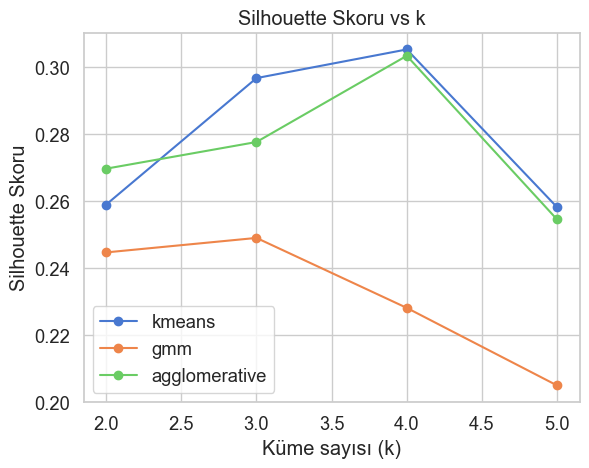

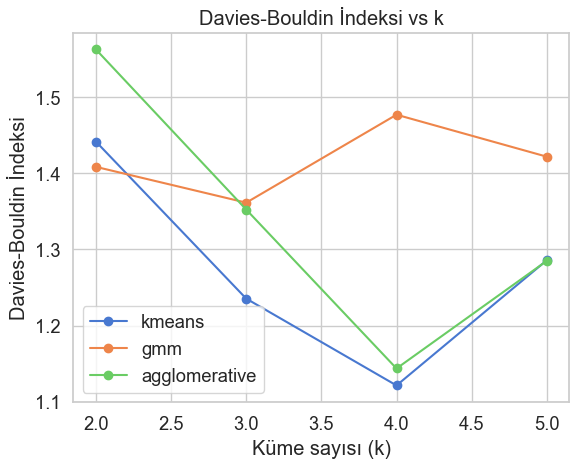

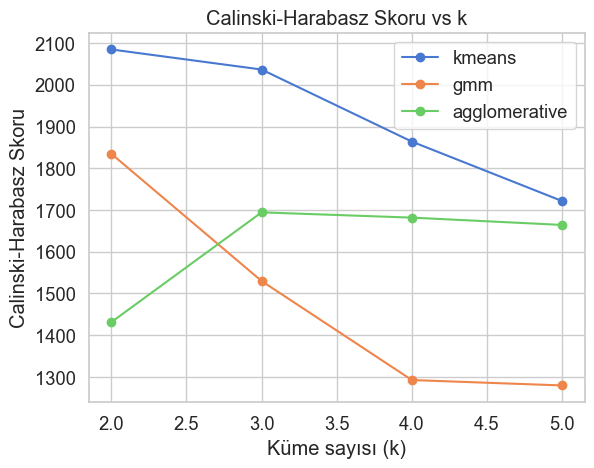

In [113]:
# Modellerin (K-means, GMM ve Agglomerative) küme sayısına göre performanslarının görselleştirilmesi

# Verilerin DataFrame olarak tanımlanması

kume = {
    'k': [2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5],
    'model': [
        'kmeans', 'gmm', 'agglomerative',
        'kmeans', 'gmm', 'agglomerative',
        'kmeans', 'gmm', 'agglomerative',
        'kmeans', 'gmm', 'agglomerative'
    ],
    'silhouette': [
        0.259032, 0.244742, 0.269755,
        0.296811, 0.249072, 0.277720,
        0.305367, 0.228168, 0.303475,
        0.258239, 0.205003, 0.254577
    ],
    'davies_bouldin': [
        1.441785, 1.408603, 1.562927,
        1.235422, 1.361536, 1.352470,
        1.121293, 1.477163, 1.143576,
        1.285905, 1.421971, 1.285098
    ],
    'calinski_harabasz': [
        2084.735262, 1834.712496, 1431.097053,
        2036.605779, 1529.736722, 1694.290003,
        1863.807352, 1292.373760, 1681.653145,
        1721.327336, 1279.430876, 1664.132355
    ]
}

df = pd.DataFrame(kume)

# Her bir metrik için ayrı grafik oluşturulması 
metrics = {
    'silhouette': 'Silhouette Skoru',
    'davies_bouldin': 'Davies-Bouldin İndeksi',
    'calinski_harabasz': 'Calinski-Harabasz Skoru'
}

for metric_key, title in metrics.items():
    plt.figure()
    for model in df['model'].unique():
        subset = df[df['model'] == model]
        plt.plot(subset['k'], subset[metric_key], marker='o', label=model)
    plt.xlabel('Küme sayısı (k)')
    plt.ylabel(title)
    plt.title(f'{title} vs k')
    plt.legend()
    plt.grid(True)
    plt.show()

## Kümeleme Yöntemi ve Farklı "k" Değerlerinin Yorumlanması:
Yukarıdaki tablo, üç algoritmanın farklı küme sayıları için performans ölçümlerini göstermektedir. Silhouette skoru yüksek olmalı, Davies–Bouldin indeksi ise düşük olmalı; Calinski–Harabasz skoru yüksek olması tercih edilir.

**KMeans:** Silhouette skorları k=3 ve k=4’te en yüksek değerleri (0.297 ve 0.305) alıyor ve Davies–Bouldin indeksi en düşük (1.121) k=4 için. Calinski–Harabasz skoru da k=4’te oldukça yüksek (1863). Bu, **KMeans’in k=4** ile iyi bir ayrım yaptığını göstermektedir.

**Agglomerative:** Benzer şekilde **k=4’te yüksek silhouette (0.303)** ve düşük DB (1.144) değeri elde ediyor, ancak *Calinski–Harabasz skoru (1681) KMeans’e göre biraz daha düşük.*

**GMM:** Tüm k değerlerinde silhouette skoru daha düşük ve Davies–Bouldin indeksi daha yüksek; dolayısıyla **kümeler arası ayrımı KMeans ve Agglomerative’e göre daha zayıf.***

Bu sonuçlara göre; KMeans ve Agglomerative yöntemleri GMM’ye kıyasla daha tutarlı performans göstermektedir. **En uygun küme sayısı için ise k=4, hem en yüksek silhouette skorunu hem de en düşük Davies–Bouldin indeksini sağladığından öne çıkmaktadır. Calinski–Harabasz skoru da k=4 için yüksek olduğundan KMeans (k=4) en dengeli seçenek gibi görünmektedir.** 

Ancak, segment seçiminde iş ihtiyaçları ve yorumlanabilirlik de önemlidir; k=4 hem analitik hem de iş açısından anlamlı segmentler sunuyorsa tercih edilebilir.

**NOT:** DBSCAN gibi yoğunluk tabanlı bir yöntem, parametrelerinin hassasiyeti ve yüksek boyutlu veri kümelerinde performans kaybı nedeniyle bu karşılaştırmaya dahil edilmemiştir. Ayrıca, veri setinde belirgin “gürültü” noktaları tespit etmek birincil amaç olmadığından ve küme sayısını doğrudan kontrol edemediğinden, K‑means ve agglomerative yöntemler daha uygun görülmüştür.

**SONUÇ:** Yapılan metrik karşılaştırmaları (silhouette, Davies–Bouldin ve Calinski‑Harabasz skorları) sonucunda **K‑means 4 kümeyle** en yüksek silhouette değerine, en düşük Davies–Bouldin indeksine ve en dengeli segment yapısına ulaştığı için tercih edilmiştir.

## 6. Kümeleme ve Görselleştirme

K-means modelinde seçilen k değerleri için (k=2, k=3, k=4, k=5) kullanıcılar kümelere ayrılmıştır. Küme sonuçlarını görselleştirmek için iki boyutlu indirgeme yöntemleri kullanılmıştır.

- **PCA (Principal Component Analysis)**: Verinin varyansını en iyi yansıtan doğrusal bileşenleri bulur ve boyutu azaltır.
- **t-SNE (t-distributed Stochastic Neighbor Embedding)**: Yüksek boyutlu veriyi iki boyuta indirerek yerel benzerlikleri korur.

Her yöntem için kümeler renklendirilerek dağılımlar çizilmiştir. Böylece hangi küme sayısında ayrımların daha belirgin olduğu gözlemlenebilmiştir.

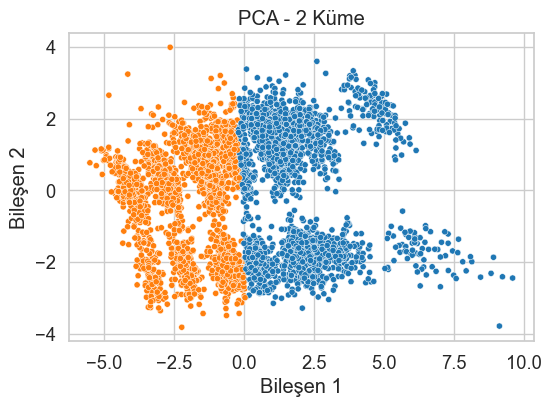

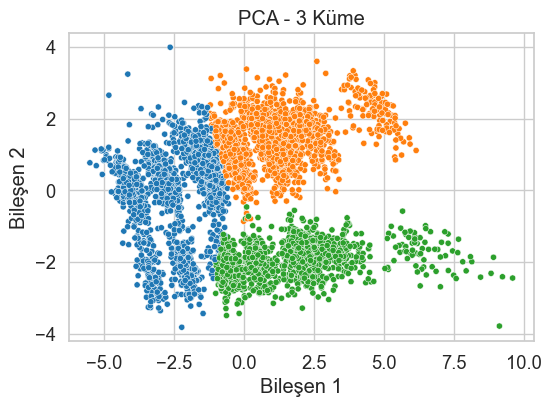

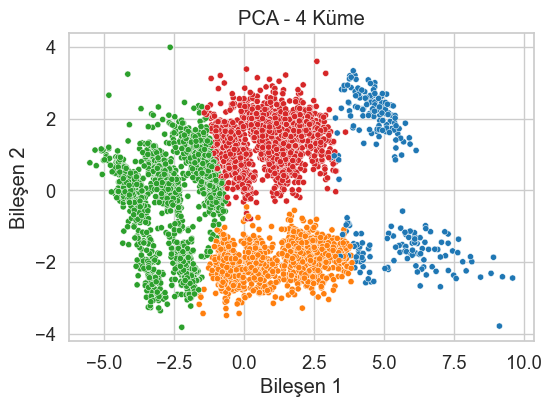

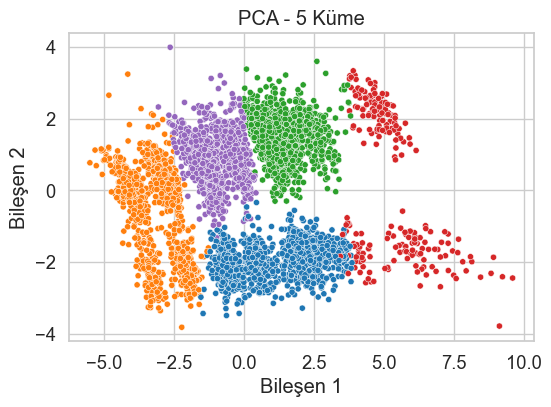

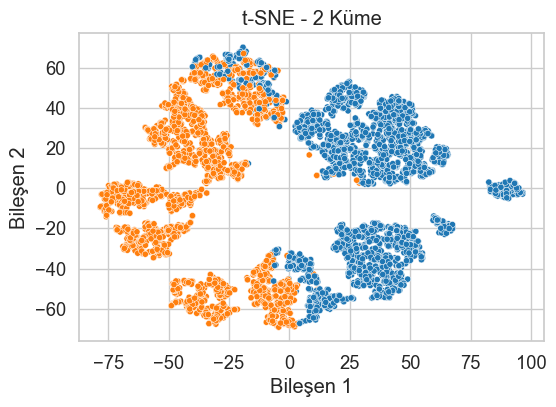

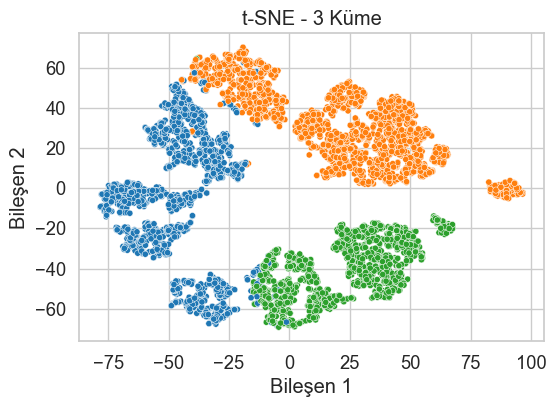

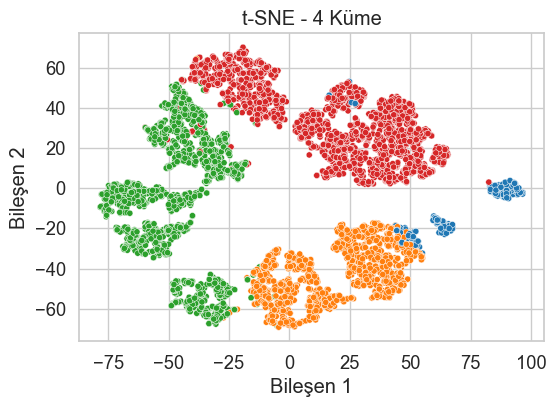

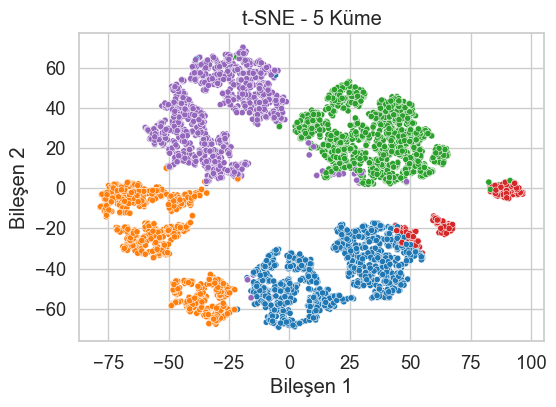

In [116]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 2 bileşenli PCA
pca = PCA(n_components=2, random_state=42)
pca_comp = pca.fit_transform(X_scaled)

# t-SNE 
tsne = TSNE(
    n_components=2, 
    random_state=42, 
    perplexity=30, 
    learning_rate=200, 
    max_iter=1000,
    init="pca"
)
tsne_comp = tsne.fit_transform(X_scaled)

# Denenecek k değerleri (k=2, k=3, k=4, k=5)
k_values = [2, 3, 4, 5]
figures=[]

for method_name, comps in [("PCA", pca_comp), ("t-SNE", tsne_comp)]:
    for k in k_values:
        km = KMeans(n_clusters=k, random_state=42, n_init=10) 
        labels = km.fit_predict(X_scaled)
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=comps[:,0], y=comps[:,1], hue=labels, palette="tab10", s=20, legend=False)
        plt.title(f"{method_name} - {k} Küme")
        plt.xlabel("Bileşen 1")
        plt.ylabel("Bileşen 2")
        plt.show()

### Küme merkezlerini görselleştirme

Kümeleme çıktısında her bir nokta tek tek gösterildiğinde, özellikle yüksek boyutlu verinin 2 boyuta indirgenmiş PCA veya t-SNE görselleştirmelerinde noktalar birbirinin üstüne binerek gürültülü ve yorumu zor bir dağılım oluşturur. 

Bu nedenle, her kümenin **merkezini (cluster center)** de görselleştirmek yorumlanabilirlik açısından önemlidir.

- Küme merkezleri, o segmente ait **tipik / ortalama kullanıcı profilini** temsil eder.  
- Noktalar karışık görünse bile, merkezler arası mesafe ve yön, kümelerin gerçekten birbirinden **ne kadar ayrıştığını** gösterir.  
- Aynı PCA veya t-SNE uzayında hem tüm kullanıcıları hem de küme merkezlerini göstermek, segmentlerin sadece matematiksel olarak değil, **görsel ve sezgisel olarak da** ayrıştığını doğrulamaya yardımcı olacaktır.  

Bu sayede, kümeleme sonuçları hem istatistiksel metriklerle (silhouette, Davies–Bouldin, Calinski–Harabasz) hem de **küme merkezleri üzerinden görsel olarak** değerlendirilecektir.

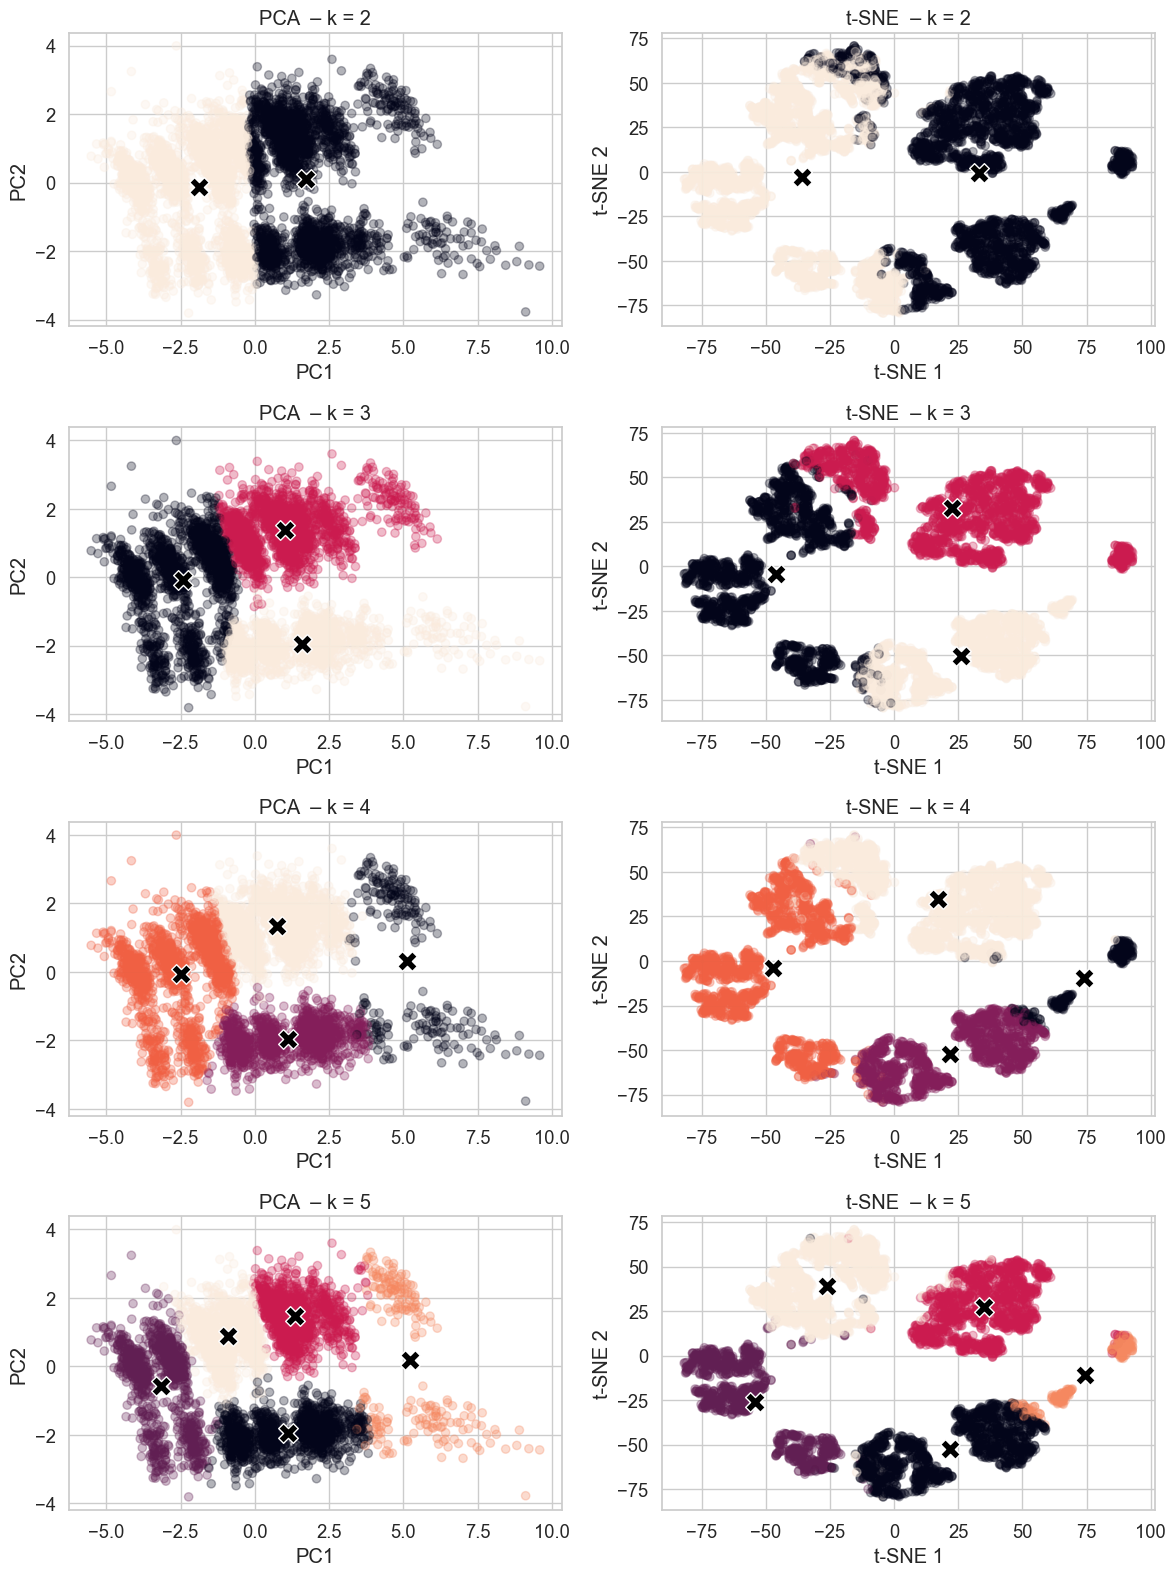

In [118]:
# PCA ve t-SNE'yi bir kez hesaplama
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=40,
    learning_rate=200,
    max_iter=2000   # n_iter yerine max_iter
)

X_tsne = tsne.fit_transform(X_scaled)

# Küme sayıları
ks = [2, 3, 4, 5]

fig, axes = plt.subplots(len(ks), 2, figsize=(12, 4 * len(ks)))

for row, k in enumerate(ks):
    # KMeans modeli
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    # Küme merkezleri (ölçeklenmiş)
    centers = kmeans.cluster_centers_
    
    # --- PCA için merkezler ---
    centers_pca = pca.transform(centers)
    
    ax_pca = axes[row, 0]
    scatter_pca = ax_pca.scatter(
        X_pca[:, 0], X_pca[:, 1],
        c=labels, alpha=0.3
    )
    ax_pca.scatter(
        centers_pca[:, 0], centers_pca[:, 1],
        c="black", s=200, marker="X", edgecolors="white"
    )
    ax_pca.set_title(f"PCA  – k = {k}")
    ax_pca.set_xlabel("PC1")
    ax_pca.set_ylabel("PC2")
    
    # --- t-SNE için merkezler ---
    # t-SNE lineer olmadığı için doğrudan transform yok;
    # bu yüzden her kümenin t-SNE uzayındaki "ağırlık merkezi"ni alıyoruz.
    centers_tsne = np.zeros((k, 2))
    for c in range(k):
        centers_tsne[c, :] = X_tsne[labels == c].mean(axis=0)
    
    ax_tsne = axes[row, 1]
    scatter_tsne = ax_tsne.scatter(
        X_tsne[:, 0], X_tsne[:, 1],
        c=labels, alpha=0.3
    )
    ax_tsne.scatter(
        centers_tsne[:, 0], centers_tsne[:, 1],
        c="black", s=200, marker="X", edgecolors="white"
    )
    ax_tsne.set_title(f"t-SNE  – k = {k}")
    ax_tsne.set_xlabel("t-SNE 1")
    ax_tsne.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

### Küme merkezlerinin yorumlanması

Küme merkezlerinin PCA ve t-SNE görsellerinde **X işaretiyle** gösterildiği bu grafikler, k=4 seçeneğinde merkezlerin hem birbirinden belirgin şekilde uzaklaştığını hem de yoğun nokta bulutlarıyla çevrelendiğini; buna karşılık k=2–3’te merkezlerin iç içe geçtiğini, k=5’te ise bazı merkezlerin gereğinden fazla yakınlaşarak aşırı bölünmüş segmentlere işaret ettiğini göstererek, hem özellik uzayında hem de t-SNE projeksiyonunda en anlamlı ayrışmanın k=4 için sağlandığını ortaya koymaktadır.

## K-Means (k=4) Modelinin Seçimi ve Yorumlanması:

- **Metriklere Dayalı Seçim:** Yapılan karşılaştırmalarda k = 2 bazı metriklerde (özellikle Davies-Bouldin ve Calinski-Harabasz) güçlü sonuçlar verse de silhouette skorunun düşük kalması, kümeler arasındaki ayrımın net olmadığını göstermektedir. Buna karşılık k = 3 ve k = 4 değerlerinde silhouette skorlarının belirgin biçimde yükseldiği ve özellikle k = 4’ün hem yüksek silhouette hem de düşük Davies-Bouldin değeri ile daha dengeli bir kümeleme yapısı sunduğu görülmektedir. Bu nedenle 4 kümelik yapı istatistiksel olarak daha tutarlı bir seçenek olarak öne çıkmaktadır.

- **İş Yorumlanabilirliği:** Küme sayısının yalnızca metriklerle değil, aynı zamanda iş açısından yorumlanabilirlikle de uyumlu olması önemlidir. k = 4 yapısında “yüksek stake – düşük kazanç”, “bonus odaklı kullanıcı”, “düşük riskli oyuncu” gibi davranışsal segmentlerin belirginleşmesi, bu küme sayısını pratik kullanım açısından da anlamlı hâle getirmektedir.

- **Aykırı Değer ve Gürültü Etkisi:** K-means, küresel kümeler varsaydığı için uç değerlerden etkilenebilir. Çalışmada uygulanan log dönüşümü ve standart ölçekleme işlemleri, aşırı değişken kullanıcı profillerinin kümeleri bozmasını engellemiş ve daha stabil sonuçlar elde edilmesini sağlamıştır.

- **Alternatif Modellerle Karşılaştırma:** GMM ve Agglomerative yöntemleri ile yapılan karşılaştırmalar sonucunda k-means, hem daha yüksek silhouette skorları hem de daha düşük Davies-Bouldin değerleri ile daha tutarlı bir performans göstermiştir. Bu nedenle nihai segmentasyon yapısında k-means tercih edilmiştir.

Sonuç olarak, istatistiksel metrikler k = 2 için daha güçlü bir ayrışma gösterse de, silhouette skorlarının düşük kalması, kümeler arası yapının yeterince belirgin olmaması ve iş açısından yorumlanabilir, anlamlı kullanıcı segmentlerinin k = 4 yapısında ortaya çıkması nedeniyle nihai modelde k = 4 tercih edilmiştir.

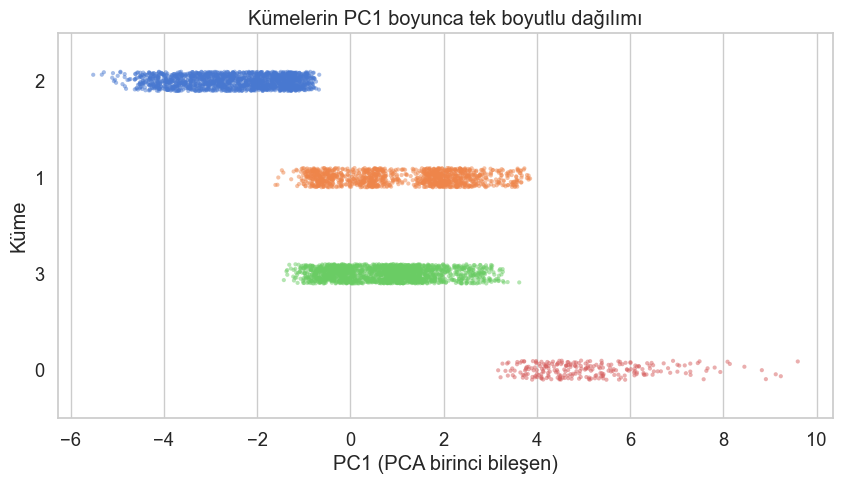

In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import seaborn as sns

# --- 1. PCA hesapla (sadece görselleştirme için) ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# İlk bileşen
pc1 = X_pca[:, 0]

k = 4  # kullanılan küme sayısı
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

pc1_df = pd.DataFrame({
    "PC1": pc1,
    "cluster": labels.astype(str)  # string yapınca seaborn’da daha düzgün etiketlenir
})

plt.figure(figsize=(10, 5))

# Y eksenine kümeyi koy, X ekseni PC1 olsun → şerit gibi görünür
sns.stripplot(
    data=pc1_df,
    x="PC1",
    y="cluster",
    hue="cluster",
    dodge=False,
    alpha=0.5,
    size=3,
    legend=False
)

plt.title("Kümelerin PC1 boyunca tek boyutlu dağılımı")
plt.xlabel("PC1 (PCA birinci bileşen)")
plt.ylabel("Küme")
plt.show()


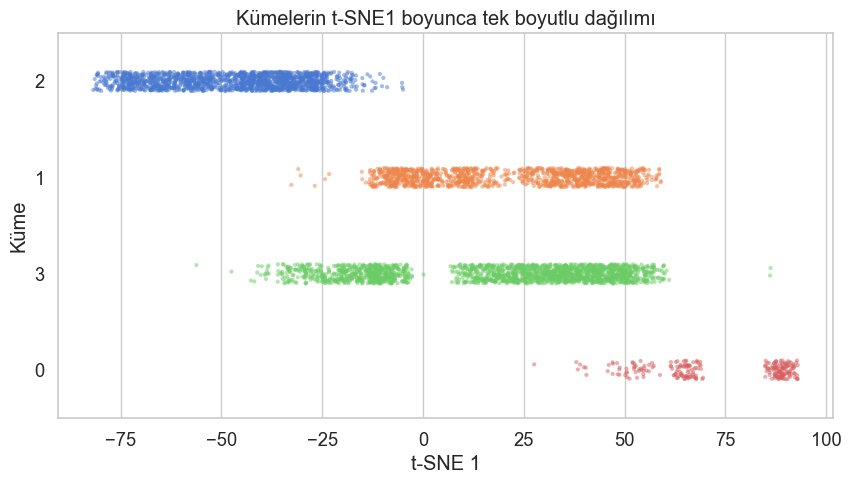

In [121]:
from sklearn.manifold import TSNE

# --- 1. t-SNE (2 bileşenli) ---
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=40,
    learning_rate=200,
    max_iter=2000
)
X_tsne = tsne.fit_transform(X_scaled)

tsne1 = X_tsne[:, 0]

tsne_df = pd.DataFrame({
    "TSNE1": tsne1,
    "cluster": labels.astype(str)
})

plt.figure(figsize=(10, 5))
sns.stripplot(
    data=tsne_df,
    x="TSNE1",
    y="cluster",
    hue="cluster",
    dodge=False,
    alpha=0.5,
    size=3,
    legend=False
)
plt.title("Kümelerin t-SNE1 boyunca tek boyutlu dağılımı")
plt.xlabel("t-SNE 1")
plt.ylabel("Küme")
plt.show()

### Tek Boyutlu Küme Dağılımının Yorumlanması

t-SNE1 ekseninde yapılan tek boyutlu dağılım grafiği, her kümenin yüksek boyutlu davranış özellikleri bakımından birbirinden ne kadar ayrıldığını sade bir biçimde göstermektedir. Bu grafikte aynı kümeye ait kullanıcıların tek bir yatay hatta toplandığı, farklı kümelerin ise eksen üzerinde farklı konumlara yerleştiği görülmektedir.

Kümeler arasındaki yatay mesafe, kullanıcı gruplarının davranışsal benzerlik veya farklılık düzeyine işaret etmektedir:

- **Bir kümenin dar ve yoğun bir bant oluşturması**, bu kümedeki kullanıcıların davranışlarının oldukça homojen olduğunu gösterir.
- **Kümeler arasındaki boşlukların geniş olması**, modelin bu segmentleri belirgin özellik farklarına göre ayırdığını gösterir.
- **Küme bantlarının üst üste binmesi**, iki küme arasında davranışsal benzerlik olabileceğine veya k sayısının artırılıp azaltılarak yeniden denenmesi gerektiğine işaret eder.

Bu grafik, t-SNE'nin eksenlerinin doğrudan bir özelliği temsil etmediğini bilmekle birlikte, modelin segmentleri yüksek boyutlu uzayda gerçekten ayırıp ayırmadığını hızlıca doğrulamak için kullanılmaktadır. Böylece küme yapısının stabil olup olmadığı ve segmentlerin iş açısından anlamlı farklar taşıyıp taşımadığı görsel olarak kolayca değerlendirilmektedir.

Grafikte **k=4** için kümelerin t-SNE1 boyunca belirgin olarak ayrıştığı görülmektedir. 
- **Küme 3 (mavi)** en üstte tek bir yoğun bant olarak durarak homojen bir kullanıcı grubunu temsil eder.
- **Küme 1 (turuncu)** geniş bir alana yayılmış olup heterojen bir davranış grubuna işaret eder.
- **Küme 0 (yeşil)** dar bir aralıkta toplanarak belirgin ortak özellikler gösterir.
- **Küme 2 (kırmızı)** eksenin uzak sağında yer alarak diğer tüm kümelerden ayrışmış bir kullanıcı segmentini temsil eder.

Bu ayrışma, modelin 4 küme yapısını istikrarlı ve davranışsal olarak anlamlı bir şekilde kurduğunu göstermektedir.

## 7. K-Means Modelinin Eğitilmesi

In [145]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# Etiketlerin kullanıcı bazlı tabloya eklenmesi

aggregated_with_clusters = aggregated.copy()
aggregated_with_clusters["cluster"] = labels  # her kullanıcıya küme etiketi atanır

# Her segment için özet tablo oluşturulması

segment_summary = (
    aggregated_with_clusters
    .groupby("cluster")
    .agg(
        segment_size=("cluster", "size"),
        avg_total_stake=("total_stake", "mean"),
        avg_total_gain=("total_gain", "mean"),
        avg_total_GGR=("total_GGR", "mean"),
        avg_win_rate=("win_rate", "mean"),
        avg_ratio_single=("ratio_single", "mean"),
        avg_ratio_multiple=("ratio_multiple", "mean"),
    )
    .round(3)  # sonuçları 3 hane yuvarlar
)

# Dosyanın kaydedilmesi (Power BI veya farklı raporlama araçlarına aktarılabilirlik)

aggregated_with_clusters.to_csv("users_with_clusters.csv", index=False)
segment_summary.to_csv("segment_summary.csv")

# Excel'e kaydetmek için:
# aggregated_with_clusters.to_excel("users_with_clusters.xlsx", index=False)
# segment_summary.to_excel("segment_summary.xlsx")

## 8. Küme Özelliklerinin İncelenmesi

t-SNE1 veya PC1 üzerinde yapılan tek boyutlu dağılım (stripplot), kümelerin yüksek boyutlu özellik uzayındaki ayrışmalarını en sade şekilde görselleştirir. Her küme eksen boyunca belirli bir konuma yerleşir.

Küme merkezleri grafik üzerinde sadece "nerede durduklarını" gösterir; *neden* orada olduklarının cevabı, merkezin içindeki özellik değerlerinin incelenmesiyle anlaşılır. Bu nedenle küme merkezlerini yorumlarken asıl odak, her merkezdeki özellik ortalamalarının birbirinden nasıl farklılaştığıdır.

In [147]:
# Küme merkezlerinin tablo olarak çıkarılması

cluster_centers_df = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=features_for_scaling
)
print(cluster_centers_df)

   log_total_stake  log_mean_stake  log_total_gain  log_mean_gain  \
0         1.632936        1.689033        1.623258       1.702873   
1         0.286618        0.283669        0.647234       0.664586   
2        -1.141592       -1.153299       -1.139663      -1.156920   
3         0.587049        0.591897        0.344167       0.337123   

   log_total_GGR  log_mean_GGR  std_stake  std_gain  win_rate  ratio_single  \
0      -0.098516     -0.089839   3.236210  3.009066  0.120214     -0.006357   
1      -1.359137     -1.384473   0.004723  0.315027  0.667975      0.009954   
2       0.113379      0.131225  -0.772146 -0.604402 -0.139519     -0.007541   
3       0.828095      0.828480   0.246234 -0.078650 -0.343478      0.000694   

   ratio_multiple  
0        0.006357  
1       -0.009954  
2        0.007541  
3       -0.000694  


In [149]:
# Her sütunun varyansını hesaplayıp en çok ayrışan özellikleri sıralama

feature_variance = cluster_centers_df.var(axis=0).sort_values(ascending=False)

print(feature_variance)

std_stake          3.095693
std_gain           2.593811
log_mean_gain      1.398250
log_mean_stake     1.371933
log_total_stake    1.310225
log_total_gain     1.309086
log_mean_GGR       0.854076
log_total_GGR      0.829648
win_rate           0.191600
ratio_single       0.000065
ratio_multiple     0.000065
dtype: float64


### Varyans analizi (ayrıştırıcı özelliklerin) yorumlanması

Aşağıdaki varyans analizi, K‑means modeli eğitildikten sonra küme merkezleri üzerinde yapılan hesaplamaya dayanmaktadır ve segmentleri en çok ayrıştıran özellikleri ortaya koymaktadır. En yüksek varyansa sahip özellikler, kümeler arasındaki farkı daha belirgin kılar.

| Özellik             | Varyans Değeri | Yorum                                                                                                                                                                                                                                                         |
| ------------------- | -------------: | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **std_stake**       |       3.095693 | Her segmentin stake tutarlarının standart sapması oldukça farklı; yani bazı segmentlerde oyuncuların stake değerleri çok tutarlı iken diğerlerinde yüksek dalgalanmalar görülüyor. Bu, risk ve oynama alışkanlıkları açısından önemli bir ayırt edici faktör. |
| **std_gain**        |       2.593811 | Kazançların standart sapması segmentler arasında belirgin şekilde değişiyor. Bazı kullanıcı grupları tutarlı kazançlar elde ederken, diğer gruplarda kazançlar çok dalgalanıyor; bu da segmentlerin davranış profillerini ayrıştırıyor.                       |
| **log_mean_gain**   |       1.398250 | Küme merkezlerinin logaritmik ortalama kazançları farklılık gösteriyor. Bazı segmentlerde ortalama kazanç yüksek (log dönüşümle ölçeklenmiş), bazılarında düşük; segmentler arası farkı anlamaya yardımcı oluyor.                                             |
| **log_mean_stake**  |       1.371933 | Log dönüşümlü ortalama stake değerleri segmentler arasında ayırıcı özellik; yüksek stake’li kullanıcılar ile daha düşük stake ile oynayan kullanıcılar farklı kümelerde toplanmış.                                                                            |
| **log_total_stake** |       1.310225 | Toplam stake’in logaritmik değeri segmentler arası önemli bir ayrım. Yüksek toplam stake yapan kullanıcılar belirli segmentlerde yoğunlaşıyor.                                                                                                                |
| **log_total_gain**  |       1.309086 | Toplam kazancın log dönüşümü de segmentler arasında belirgin; yüksek kazançlı kullanıcılar, diğerlerinden farklı bir segmenti oluşturuyor.                                                                                                                    |
| **log_mean_GGR**    |       0.854076 | Ortalama GGR (gross gaming revenue) değerleri segmentler arasında orta derecede farklılık gösteriyor; bazı gruplar daha yüksek GGR üretiyor.                                                                                                                  |
| **log_total_GGR**   |       0.829648 | Toplam GGR’deki farklar segment ayrımına katkı sağlıyor; toplamda yüksek GGR üreten kullanıcılar ayrı bir grup oluşturuyor.                                                                                                                                   |
| **win_rate**        |       0.191600 | Kazanma oranı segmentler arasında daha az oynaklık gösteriyor fakat hâlâ bir dereceye kadar ayırt edici; bazı segmentler ortalamanın üzerinde kazanma oranına sahip.                                                                                          |
| **ratio_single**    |       0.000065 | Tekli bahis oranı neredeyse sabit; bu oran tüm segmentlerde birbirine çok yakın olduğundan kümeleri ayırmakta etkisi yok denecek kadar az.                                                                                                                    |
| **ratio_multiple**  |       0.000065 | Çoklu bahis oranı da oldukça sabit; segmentler arasında farklılık yaratmıyor.                                                                                                                                                                                 |

**Genel değerlendirme:** Parasal büyüklükler ve onların log dönüşümlü ortalama/toplam değerleri (özellikle std_stake, std_gain ve log_mean_gain) segmentler arasında en fazla farklılık yaratan özellikler. Bu, risk profili ve oyun tutarı açısından segmentlerin ayırt edildiğini gösteriyor. Buna karşılık, ratio_single ve ratio_multiple gibi bahis türü oranları tüm segmentlerde neredeyse aynı seviyede olduğu için ayrıştırıcı değil. Bu bulgulardan yola çıkarak, segmentlerin tanımını yaparken öncelikle stake ve kazanç istatistiklerine odaklanmak, bahis türü oranlarına ise daha az önem vermek gerekir.

In [153]:
# Her kümenin özet profilinin çıkarılması (mean, median)

cluster_profile = aggregated.copy()
cluster_profile["cluster"] = labels

cluster_summary = cluster_profile.groupby("cluster").mean().round(3)
cluster_summary

,bet_count,single_count,multiple_count,total_stake,mean_stake,std_stake,total_gain,mean_gain,std_gain,win_rate,...,sport_Badminton_count,sport_Badminton_ratio,sport_Cycling_count,sport_Cycling_ratio,log_total_stake,log_mean_stake,log_total_gain,log_mean_gain,log_total_GGR,log_mean_GGR
cluster,,,,,,,,,,,,,,,,,,,,,
0,20.242,13.148,7.094,12230.131,602.775,165.494,12525.522,618.412,1212.051,0.378,...,0.098,0.005,0.033,0.002,9.344,6.363,9.294,6.313,0.937,-0.623
1,20.051,13.078,6.973,2561.086,127.922,40.667,3442.926,173.678,330.277,0.439,...,0.102,0.005,0.054,0.003,7.590,4.628,7.895,4.930,-6.894,-6.808
2,19.673,12.765,6.908,425.983,21.763,10.658,294.850,14.850,29.342,0.349,...,0.107,0.005,0.062,0.003,5.730,2.854,5.334,2.503,2.254,0.433
3,20.219,13.140,7.079,3401.439,169.218,49.996,2170.727,106.871,201.424,0.326,...,0.102,0.005,0.068,0.003,7.982,5.009,7.461,4.494,6.694,3.764


In [155]:
# Her küme için otomatik davranış yorumu 

for c in range(kmeans.n_clusters):
    group = cluster_profile[cluster_profile["cluster"] == c]
    print(f"\n Küme {c} - Kullanıcı sayısı: {len(group)}")

    means = group.mean().sort_values(ascending=False)

    print("\nEn yüksek özellikler:")
    display(means.head(5))

    print("\nEn düşük özellikler:")
    display(means.tail(5))


 Küme 0 - Kullanıcı sayısı: 244

En yüksek özellikler:


total_gain     12525.521598
total_stake    12230.130738
std_gain        1212.050746
std_GGR         1207.210240
mean_gain        618.411935
dtype: float64


En düşük özellikler:


sport_Cycling_ratio      0.001815
cluster                  0.000000
log_mean_GGR            -0.622820
mean_GGR               -15.636546
total_GGR             -295.390861
dtype: float64


 Küme 1 - Kullanıcı sayısı: 1258

En yüksek özellikler:


...

sport_Table Tennis_ratio    0.019947
sport_Rugby_ratio           0.019302
sport_Formula 1_ratio       0.007058
sport_Badminton_ratio       0.005433
sport_Cycling_ratio         0.003104
dtype: float64


 Küme 3 - Kullanıcı sayısı: 1871

En yüksek özellikler:


total_stake    3401.439150
total_gain     2170.727007
total_GGR      1230.712143
std_GGR         203.400808
std_gain        201.424194
dtype: float64


En düşük özellikler:


sport_Rugby_ratio           0.020247
sport_Table Tennis_ratio    0.018883
sport_Formula 1_ratio       0.006818
sport_Badminton_ratio       0.004866
sport_Cycling_ratio         0.003427
dtype: float64

## Değerlendirme

Küme 0 (244 kullanıcı) – Analizinizdeki en küçük segment. Toplam ve ortalama stake/gain değerleri çok yüksek; standart sapmalar da büyük olduğu için oyuncu davranışları oldukça dalgalı. Bu grup yüksek hacimli, yüksek riskli “whale” oyuncuları temsil ediyor.

Küme 1 (1258 kullanıcı) – Orta büyüklükte bir segment. Toplam stake ve gain’ler küme 0’a göre daha düşük, ancak hâlâ diğer segmentlerden yüksek. Kazançların ve GGR’nin varyansı yüksek; bu nedenle bu grup tutarlı değil ama yüksek hacimli değil. “Orta seviye” oyuncular olarak görülebilir.

Küme 2 (1627 kullanıcı) – En büyük segment. Toplam/ortalama stake ve gain değerleri çok düşük, GGR ve varyanslar da küçük. Bu kullanıcılar daha çok düşük stake’li, istikrarlı “casual” oyuncular.

Küme 3 (1871 kullanıcı) – Stake ve gain değerleri küme 1’den yüksek, ancak küme 0 kadar ekstrem değil. Büyük bir segment olması, yüksek hacimli ama daha tutarlı oyuncuları işaret ediyor. Bu grup “yüksek hacimli, orta riskli” oyuncular gibi değerlendirilebilir.

# 